<a href="https://colab.research.google.com/github/SharanyaKUMAR22/Tomato-Disease-Detection/blob/main/Performance_Evaluation_Metrices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
MODEL_PATH = "/content/drive/MyDrive/Tomato_Disease_Project/tomato_disease_model.keras"

print(os.path.exists(MODEL_PATH))

True


In [6]:
import tensorflow as tf

MODEL_PATH = "/content/drive/MyDrive/Tomato_Disease_Project/tomato_disease_model.keras"

model = tf.keras.models.load_model(MODEL_PATH)

print(" Model loaded successfully!")
print("Input :", model.input_shape)
print("Output:", model.output_shape)

 Model loaded successfully!
Input : (None, 224, 224, 3)
Output: (None, 10)


In [7]:
print("GPU:", tf.config.list_physical_devices("GPU"))

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [11]:
import tensorflow as tf
import numpy as np

DATA_DIR = "/content/drive/MyDrive/Tomato_Disease_Project/data"

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 42

train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.20,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

class_names = train_dataset.class_names

print("Classes:")
for i, name in enumerate(class_names):
    print(i, ":", name)

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)
val_dataset = val_dataset.prefetch(AUTOTUNE)

print("\n Dataset ready!")

Found 16011 files belonging to 10 classes.
Using 12809 files for training.
Found 16011 files belonging to 10 classes.
Using 3202 files for validation.
Classes:
0 : Tomato_Bacterial_spot
1 : Tomato_Early_blight
2 : Tomato_Late_blight
3 : Tomato_Leaf_Mold
4 : Tomato_Septoria_leaf_spot
5 : Tomato_Spider_mites_Two_spotted_spider_mite
6 : Tomato__Target_Spot
7 : Tomato__Tomato_YellowLeaf__Curl_Virus
8 : Tomato__Tomato_mosaic_virus
9 : Tomato_healthy

 Dataset ready!


In [12]:
from tensorflow.keras import layers

augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.10)
], name="augmentation")

print("Augmentation ready!")

Augmentation ready!


In [13]:
inputs = tf.keras.Input(shape=(224, 224, 3))

x = augmentation(inputs)

# Pass augmented images through your existing trained model
outputs = model(x, training=False)

model_v2 = tf.keras.Model(inputs, outputs)

print("Fine-tuning model created")
print("Output:", model_v2.output_shape)

Fine-tuning model created
Output: (None, 10)


In [14]:
# Freeze everything
for layer in model_v2.layers:
    layer.trainable = False

# Unfreeze the last 30 layers
for layer in model_v2.layers[-30:]:
    layer.trainable = True

print(
    "Trainable layers:",
    sum(layer.trainable for layer in model_v2.layers)
)

Trainable layers: 3


In [21]:
import shutil

SOURCE = "/content/drive/MyDrive/Tomato_Disease_Project/data"
DEST = "/content/data"

print("Copying complete dataset...")
shutil.copytree(SOURCE, DEST)

print(" Complete dataset copied!")

Copying complete dataset...
 Complete dataset copied!


In [24]:
import os

classes = sorted(os.listdir("/content/data"))

print("Number of classes:", len(classes))
print("\nClasses and image counts:")

total = 0

for c in classes:
    path = os.path.join("/content/data", c)
    count = len(os.listdir(path))
    total += count
    print(c, ":", count)

print("\nTOTAL IMAGES:", total)

Number of classes: 10

Classes and image counts:
Tomato_Bacterial_spot : 2127
Tomato_Early_blight : 1000
Tomato_Late_blight : 1909
Tomato_Leaf_Mold : 952
Tomato_Septoria_leaf_spot : 1771
Tomato_Spider_mites_Two_spotted_spider_mite : 1676
Tomato__Target_Spot : 1404
Tomato__Tomato_YellowLeaf__Curl_Virus : 3209
Tomato__Tomato_mosaic_virus : 373
Tomato_healthy : 1591

TOTAL IMAGES: 16012


In [25]:
import tensorflow as tf

DATA_DIR = "/content/data"

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 42

train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.20,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

class_names = train_dataset.class_names

train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.prefetch(tf.data.AUTOTUNE)

print(" Datasets ready!")
print("Classes:", len(class_names))

Found 16011 files belonging to 10 classes.
Using 12809 files for training.
Found 16011 files belonging to 10 classes.
Using 3202 files for validation.
 Datasets ready!
Classes: 10


In [26]:
from tensorflow.keras import layers

augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.10)
], name="augmentation")

print("Augmentation ready!")

Augmentation ready!


In [27]:
inputs = tf.keras.Input(shape=(224, 224, 3))

x = augmentation(inputs)

outputs = model(x, training=False)

model_v2 = tf.keras.Model(
    inputs=inputs,
    outputs=outputs
)

print("Model V2 created!")
print("Input :", model_v2.input_shape)
print("Output:", model_v2.output_shape)

Model V2 created!
Input : (None, 224, 224, 3)
Output: (None, 10)


In [28]:
# Freeze all layers first
for layer in model_v2.layers:
    layer.trainable = False

# Unfreeze only the last 30 layers
for layer in model_v2.layers[-30:]:
    layer.trainable = True

trainable_layers = sum(
    1 for layer in model_v2.layers
    if layer.trainable
)

print("Total layers:", len(model_v2.layers))
print("Trainable layers:", trainable_layers)
print("Frozen layers:", len(model_v2.layers) - trainable_layers)

Total layers: 3
Trainable layers: 3
Frozen layers: 0


In [29]:
# Freeze the entire original model
model.trainable = False

# Unfreeze only the last 30 layers INSIDE the original model
for layer in model.layers[-30:]:
    layer.trainable = True

# Keep augmentation trainable
augmentation.trainable = True

print("Original model layers:", len(model.layers))

trainable_layers = sum(
    1 for layer in model.layers
    if layer.trainable
)

print("Trainable original-model layers:", trainable_layers)
print("Total original-model layers:", len(model.layers))

Original model layers: 243
Trainable original-model layers: 30
Total original-model layers: 243


In [30]:
model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print(" Model compiled successfully!")

 Model compiled successfully!


In [31]:
# ============================================
# STEP 9 — TRAIN MODEL V2
# ============================================

SAVE_PATH = "/content/drive/MyDrive/Tomato_Disease_Project/tomato_disease_model_v2.keras"

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=2,
        mode="max",
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=1,
        min_lr=1e-7,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        SAVE_PATH,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    )
]

print(" Starting fine-tuning...")
print("Training images: 12809")
print("Validation images: 3202")
print("Epochs: 3")

history = model_v2.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=3,
    callbacks=callbacks
)

print("\n FINE-TUNING COMPLETE!")
print("Best model saved at:")
print(SAVE_PATH)

 Starting fine-tuning...
Training images: 12809
Validation images: 3202
Epochs: 3
Epoch 1/3
801/801 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.7343 - loss: 1.0867
Epoch 1: val_accuracy improved from None to 0.84291, saving model to /content/drive/MyDrive/Tomato_Disease_Project/tomato_disease_model_v2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Tomato_Disease_Project/tomato_disease_model_v2.keras
801/801 ━━━━━━━━━━━━━━━━━━━━ 76s 79ms/step - accuracy: 0.7505 - loss: 1.0096 - val_accuracy: 0.8429 - val_loss: 0.7353 - learning_rate: 1.0000e-05
Epoch 2/3
800/801 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.7922 - loss: 0.7961
Epoch 2: val_accuracy improved from 0.84291 to 0.85946, saving model to /content/drive/MyDrive/Tomato_Disease_Project/tomato_disease_model_v2.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Tomato_Disease_Project/tomato_disease_model_v2.keras
801/801 ━━━━━━━━━━━━━━━━━━━━ 59s 73ms/step - accuracy: 0.8007 - loss: 0.7516 - val_a

In [33]:
# Continue fine-tuning for 5 more epochs

history_more = model_v2.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=5,
    initial_epoch=3,
    callbacks=callbacks
)

print(" Additional fine-tuning complete!")

Epoch 4/5
800/801 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.8551 - loss: 0.5129
Epoch 4: val_accuracy improved from 0.87820 to 0.88944, saving model to /content/drive/MyDrive/Tomato_Disease_Project/tomato_disease_model_v2.keras

Epoch 4: finished saving model to /content/drive/MyDrive/Tomato_Disease_Project/tomato_disease_model_v2.keras
801/801 ━━━━━━━━━━━━━━━━━━━━ 65s 81ms/step - accuracy: 0.8560 - loss: 0.5077 - val_accuracy: 0.8894 - val_loss: 0.4799 - learning_rate: 1.0000e-05
Epoch 5/5
800/801 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.8642 - loss: 0.4702
Epoch 5: val_accuracy did not improve from 0.88944
801/801 ━━━━━━━━━━━━━━━━━━━━ 57s 71ms/step - accuracy: 0.8671 - loss: 0.4608 - val_accuracy: 0.8888 - val_loss: 0.4761 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 4.
 Additional fine-tuning complete!


In [34]:
import tensorflow as tf

MODEL_V2_PATH = "/content/drive/MyDrive/Tomato_Disease_Project/tomato_disease_model_v2.keras"

model_v2 = tf.keras.models.load_model(MODEL_V2_PATH)

print(" Best V2 loaded")
print("Input :", model_v2.input_shape)
print("Output:", model_v2.output_shape)

 Best V2 loaded
Input : (None, 224, 224, 3)
Output: (None, 10)


In [35]:
print("V2 layers:")

for i, layer in enumerate(model_v2.layers):
    print(i, layer.name, type(layer).__name__)

V2 layers:
0 input_layer_2 InputLayer
1 augmentation Sequential
2 functional_2 Functional


In [36]:
base_model = model_v2.layers[-1]

print("Base model:", base_model.name)
print("Base model layers:", len(base_model.layers))

Base model: functional_2
Base model layers: 243


In [37]:
model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-6
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled with LR = 1e-6")

Model compiled with LR = 1e-6


In [38]:
SAVE_PATH = "/content/drive/MyDrive/Tomato_Disease_Project/tomato_disease_model_v3.keras"

callbacks_v3 = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        mode="max",
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=1,
        min_lr=1e-8,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        SAVE_PATH,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    )
]

history_v3 = model_v2.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=8,
    callbacks=callbacks_v3
)

Epoch 1/8
800/801 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.8672 - loss: 0.4605
Epoch 1: val_accuracy improved from None to 0.88726, saving model to /content/drive/MyDrive/Tomato_Disease_Project/tomato_disease_model_v3.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Tomato_Disease_Project/tomato_disease_model_v3.keras
801/801 ━━━━━━━━━━━━━━━━━━━━ 71s 74ms/step - accuracy: 0.8677 - loss: 0.4597 - val_accuracy: 0.8873 - val_loss: 0.4978 - learning_rate: 1.0000e-06
Epoch 2/8
800/801 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.8664 - loss: 0.4584
Epoch 2: val_accuracy improved from 0.88726 to 0.88976, saving model to /content/drive/MyDrive/Tomato_Disease_Project/tomato_disease_model_v3.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Tomato_Disease_Project/tomato_disease_model_v3.keras
801/801 ━━━━━━━━━━━━━━━━━━━━ 57s 71ms/step - accuracy: 0.8665 - loss: 0.4650 - val_accuracy: 0.8898 - val_loss: 0.4790 - learning_rate: 1.0000e-06
Epoch 3/8
800/801 ━

In [39]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

MODEL_V3_PATH = "/content/drive/MyDrive/Tomato_Disease_Project/tomato_disease_model_v3.keras"

model_v3 = tf.keras.models.load_model(MODEL_V3_PATH)

y_true_v3 = []
y_prob_v3 = []

print("Evaluating V3...")

for images, labels in val_dataset:
    probs = model_v3(images, training=False).numpy()

    y_prob_v3.append(probs)
    y_true_v3.append(labels.numpy())

y_prob_v3 = np.concatenate(y_prob_v3)
y_true_v3 = np.concatenate(y_true_v3)

y_true_v3 = np.argmax(y_true_v3, axis=1)
y_pred_v3 = np.argmax(y_prob_v3, axis=1)

print("Images evaluated:", len(y_true_v3))

print("\nCLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_true_v3,
        y_pred_v3,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

Evaluating V3...
Images evaluated: 3202

CLASSIFICATION REPORT
                                             precision    recall  f1-score   support

                      Tomato_Bacterial_spot     0.0000    0.0000    0.0000         0
                        Tomato_Early_blight     0.0000    0.0000    0.0000         0
                         Tomato_Late_blight     0.0000    0.0000    0.0000         0
                           Tomato_Leaf_Mold     0.0000    0.0000    0.0000         0
                  Tomato_Septoria_leaf_spot     0.0000    0.0000    0.0000         0
Tomato_Spider_mites_Two_spotted_spider_mite     0.0000    0.0000    0.0000         0
                        Tomato__Target_Spot     0.0000    0.0000    0.0000         0
      Tomato__Tomato_YellowLeaf__Curl_Virus     0.9932    0.9370    0.9643      1238
                Tomato__Tomato_mosaic_virus     1.0000    0.4102    0.5817       373
                             Tomato_healthy     0.9753    0.9667    0.9710      1591



In [40]:
import numpy as np

label_counts = np.bincount(
    y_true_v3,
    minlength=len(class_names)
)

print("Validation class distribution:")
print("=" * 60)

for i, name in enumerate(class_names):
    print(f"{i}: {name} → {label_counts[i]} images")

Validation class distribution:
0: Tomato_Bacterial_spot → 0 images
1: Tomato_Early_blight → 0 images
2: Tomato_Late_blight → 0 images
3: Tomato_Leaf_Mold → 0 images
4: Tomato_Septoria_leaf_spot → 0 images
5: Tomato_Spider_mites_Two_spotted_spider_mite → 0 images
6: Tomato__Target_Spot → 0 images
7: Tomato__Tomato_YellowLeaf__Curl_Virus → 1238 images
8: Tomato__Tomato_mosaic_virus → 373 images
9: Tomato_healthy → 1591 images


In [41]:
print("Validation batches:", tf.data.experimental.cardinality(val_dataset).numpy())

for images, labels in val_dataset.take(1):
    print("Image shape:", images.shape)
    print("Label shape:", labels.shape)
    print("Labels in first batch:", np.unique(np.argmax(labels.numpy(), axis=1)))

Validation batches: 201
Image shape: (16, 224, 224, 3)
Label shape: (16, 10)
Labels in first batch: [7]


In [42]:
print("Training labels:")

train_counts = np.zeros(10, dtype=int)

for _, labels in train_dataset:
    ids = np.argmax(labels.numpy(), axis=1)
    train_counts += np.bincount(ids, minlength=10)

for i, name in enumerate(class_names):
    print(i, name, "→", train_counts[i])

Training labels:
0 Tomato_Bacterial_spot → 1706
1 Tomato_Early_blight → 815
2 Tomato_Late_blight → 1539
3 Tomato_Leaf_Mold → 761
4 Tomato_Septoria_leaf_spot → 1399
5 Tomato_Spider_mites_Two_spotted_spider_mite → 1354
6 Tomato__Target_Spot → 1117
7 Tomato__Tomato_YellowLeaf__Curl_Virus → 2536
8 Tomato__Tomato_mosaic_virus → 305
9 Tomato_healthy → 1277


In [43]:
import os
import shutil
import random

SOURCE = "/content/data"
SPLIT_DIR = "/content/tomato_split"

random.seed(42)

# Delete old split if it exists
if os.path.exists(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)

train_dir = os.path.join(SPLIT_DIR, "train")
val_dir = os.path.join(SPLIT_DIR, "val")

os.makedirs(train_dir)
os.makedirs(val_dir)

classes = sorted([
    c for c in os.listdir(SOURCE)
    if os.path.isdir(os.path.join(SOURCE, c))
])

for class_name in classes:

    source_class = os.path.join(SOURCE, class_name)

    train_class = os.path.join(train_dir, class_name)
    val_class = os.path.join(val_dir, class_name)

    os.makedirs(train_class)
    os.makedirs(val_class)

    images = [
        f for f in os.listdir(source_class)
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png", ".bmp", ".webp")
        )
    ]

    random.shuffle(images)

    split_index = int(len(images) * 0.8)

    train_images = images[:split_index]
    val_images = images[split_index:]

    for filename in train_images:
        shutil.copy2(
            os.path.join(source_class, filename),
            os.path.join(train_class, filename)
        )

    for filename in val_images:
        shutil.copy2(
            os.path.join(source_class, filename),
            os.path.join(val_class, filename)
        )

    print(
        class_name,
        "→ train:", len(train_images),
        "| validation:", len(val_images)
    )

print("\n PROPER 80/20 SPLIT CREATED!")
print("Train:", train_dir)
print("Validation:", val_dir)

Tomato_Bacterial_spot → train: 1701 | validation: 426
Tomato_Early_blight → train: 800 | validation: 200
Tomato_Late_blight → train: 1527 | validation: 382
Tomato_Leaf_Mold → train: 761 | validation: 191
Tomato_Septoria_leaf_spot → train: 1416 | validation: 355
Tomato_Spider_mites_Two_spotted_spider_mite → train: 1340 | validation: 336
Tomato__Target_Spot → train: 1123 | validation: 281
Tomato__Tomato_YellowLeaf__Curl_Virus → train: 2566 | validation: 642
Tomato__Tomato_mosaic_virus → train: 298 | validation: 75
Tomato_healthy → train: 1272 | validation: 319

 PROPER 80/20 SPLIT CREATED!
Train: /content/tomato_split/train
Validation: /content/tomato_split/val


In [44]:
for split in ["train", "val"]:

    path = os.path.join(SPLIT_DIR, split)

    print("\n", split.upper())

    total = 0

    for class_name in sorted(os.listdir(path)):

        count = len(os.listdir(
            os.path.join(path, class_name)
        ))

        total += count

        print(class_name, ":", count)

    print("TOTAL:", total)


 TRAIN
Tomato_Bacterial_spot : 1701
Tomato_Early_blight : 800
Tomato_Late_blight : 1527
Tomato_Leaf_Mold : 761
Tomato_Septoria_leaf_spot : 1416
Tomato_Spider_mites_Two_spotted_spider_mite : 1340
Tomato__Target_Spot : 1123
Tomato__Tomato_YellowLeaf__Curl_Virus : 2566
Tomato__Tomato_mosaic_virus : 298
Tomato_healthy : 1272
TOTAL: 12804

 VAL
Tomato_Bacterial_spot : 426
Tomato_Early_blight : 200
Tomato_Late_blight : 382
Tomato_Leaf_Mold : 191
Tomato_Septoria_leaf_spot : 355
Tomato_Spider_mites_Two_spotted_spider_mite : 336
Tomato__Target_Spot : 281
Tomato__Tomato_YellowLeaf__Curl_Virus : 642
Tomato__Tomato_mosaic_virus : 75
Tomato_healthy : 319
TOTAL: 3207


In [45]:
import tensorflow as tf

TRAIN_DIR = "/content/tomato_split/train"
VAL_DIR = "/content/tomato_split/val"

IMG_SIZE = (224, 224)
BATCH_SIZE = 16

train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=42
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

class_names = train_dataset.class_names

print("\nClasses:")
for i, name in enumerate(class_names):
    print(i, ":", name)

train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.prefetch(tf.data.AUTOTUNE)

print("\n CORRECT 10-CLASS DATASETS READY!")

Found 12804 files belonging to 10 classes.
Found 3207 files belonging to 10 classes.

Classes:
0 : Tomato_Bacterial_spot
1 : Tomato_Early_blight
2 : Tomato_Late_blight
3 : Tomato_Leaf_Mold
4 : Tomato_Septoria_leaf_spot
5 : Tomato_Spider_mites_Two_spotted_spider_mite
6 : Tomato__Target_Spot
7 : Tomato__Tomato_YellowLeaf__Curl_Virus
8 : Tomato__Tomato_mosaic_virus
9 : Tomato_healthy

 CORRECT 10-CLASS DATASETS READY!


In [46]:
MODEL_PATH = "/content/drive/MyDrive/Tomato_Disease_Project/tomato_disease_model.keras"

model = tf.keras.models.load_model(MODEL_PATH)

print(" Original model loaded!")
print(model.input_shape)
print(model.output_shape)

 Original model loaded!
(None, 224, 224, 3)
(None, 10)


In [47]:
from tensorflow.keras import layers

augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.10)
], name="augmentation")

print("Augmentation ready!")

Augmentation ready!


In [48]:
inputs = tf.keras.Input(shape=(224, 224, 3))

x = augmentation(inputs)
outputs = model(x, training=False)

model_v4 = tf.keras.Model(
    inputs=inputs,
    outputs=outputs
)

print(" Model V4 created!")
print("Input:", model_v4.input_shape)
print("Output:", model_v4.output_shape)

 Model V4 created!
Input: (None, 224, 224, 3)
Output: (None, 10)


In [49]:
# Freeze original model
model.trainable = False

# Unfreeze last 30 layers
for layer in model.layers[-30:]:
    layer.trainable = True

augmentation.trainable = True

print(
    "Trainable layers:",
    sum(layer.trainable for layer in model.layers)
)

Trainable layers: 30


In [50]:
model_v4.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model V4 compiled!")

Model V4 compiled!


In [51]:
SAVE_PATH = "/content/drive/MyDrive/Tomato_Disease_Project/tomato_disease_model_v4.keras"

callbacks_v4 = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=2,
        mode="max",
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=1,
        min_lr=1e-7,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        SAVE_PATH,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    )
]

history_v4 = model_v4.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=5,
    callbacks=callbacks_v4
)

Epoch 1/5
801/801 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.7386 - loss: 1.0648
Epoch 1: val_accuracy improved from None to 0.93764, saving model to /content/drive/MyDrive/Tomato_Disease_Project/tomato_disease_model_v4.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Tomato_Disease_Project/tomato_disease_model_v4.keras
801/801 ━━━━━━━━━━━━━━━━━━━━ 72s 75ms/step - accuracy: 0.7648 - loss: 0.9228 - val_accuracy: 0.9376 - val_loss: 0.2140 - learning_rate: 1.0000e-05
Epoch 2/5
800/801 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.8298 - loss: 0.6369
Epoch 2: val_accuracy improved from 0.93764 to 0.94263, saving model to /content/drive/MyDrive/Tomato_Disease_Project/tomato_disease_model_v4.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Tomato_Disease_Project/tomato_disease_model_v4.keras
801/801 ━━━━━━━━━━━━━━━━━━━━ 58s 72ms/step - accuracy: 0.8311 - loss: 0.6266 - val_accuracy: 0.9426 - val_loss: 0.1988 - learning_rate: 1.0000e-05
Epoch 3/5
800/801 ━

In [52]:
MODEL_V4_PATH = "/content/drive/MyDrive/Tomato_Disease_Project/tomato_disease_model_v4.keras"

model_v4 = tf.keras.models.load_model(MODEL_V4_PATH)

print(" Best V4 model loaded")

 Best V4 model loaded


In [53]:
results = model_v4.evaluate(
    val_dataset,
    verbose=1
)

print("\nValidation loss:", results[0])
print("Validation accuracy:", results[1])

201/201 ━━━━━━━━━━━━━━━━━━━━ 13s 46ms/step - accuracy: 0.9548 - loss: 0.1484

Validation loss: 0.14844970405101776
Validation accuracy: 0.9547864198684692


In [54]:
import numpy as np

y_true = []
y_prob = []

print("Generating predictions...")

for images, labels in val_dataset:
    probabilities = model_v4(images, training=False).numpy()

    y_prob.append(probabilities)
    y_true.append(labels.numpy())

y_prob = np.concatenate(y_prob)
y_true = np.concatenate(y_true)

y_true = np.argmax(y_true, axis=1)
y_pred = np.argmax(y_prob, axis=1)

print(" Predictions complete!")
print("Images:", len(y_true))
print("Probability shape:", y_prob.shape)

Generating predictions...
 Predictions complete!
Images: 3207
Probability shape: (3207, 10)


In [55]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

print("================================")
print("FINAL MODEL METRICS")
print("================================")

print(f"Accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall   : {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score : {f1:.4f} ({f1*100:.2f}%)")

FINAL MODEL METRICS
Accuracy : 0.9548 (95.48%)
Precision: 0.9581 (95.81%)
Recall   : 0.9548 (95.48%)
F1-Score : 0.9554 (95.54%)


In [59]:
import numpy as np
from sklearn.preprocessing import label_binarize

# Convert class labels to one-vs-rest format
y_true_binary = label_binarize(
    y_true,
    classes=np.arange(len(class_names))
)

print("y_true_binary shape:", y_true_binary.shape)
print("y_prob shape:", y_prob.shape)

y_true_binary shape: (3207, 10)
y_prob shape: (3207, 10)


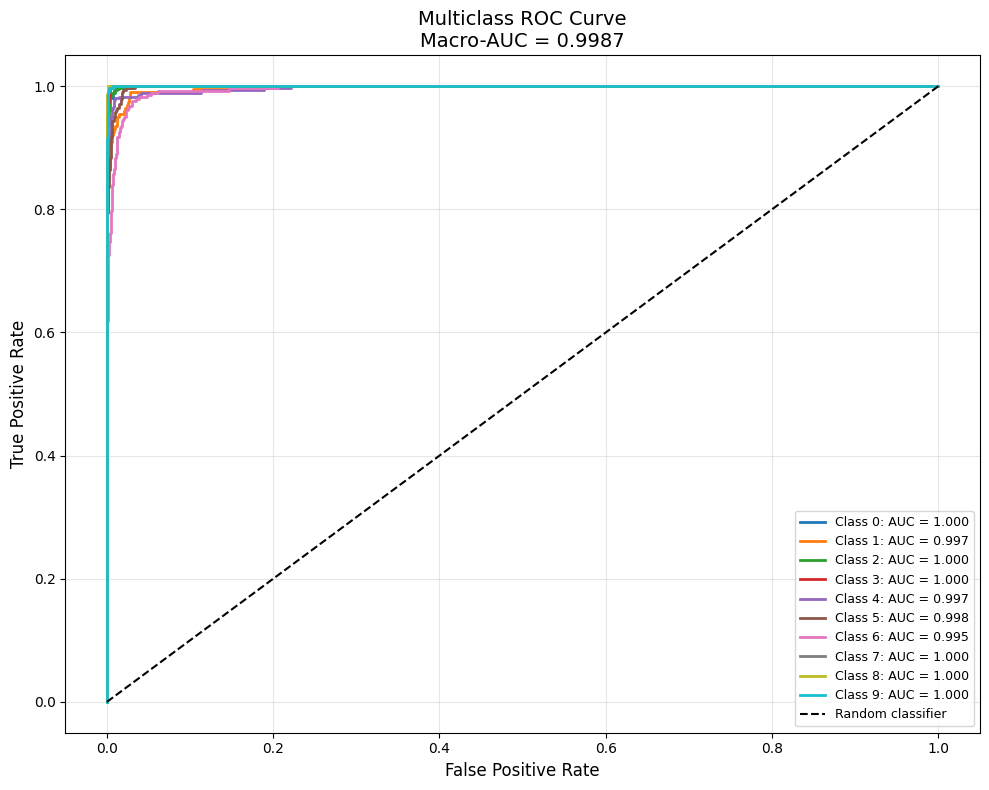

Macro AUC = 0.9987


In [61]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

auc_scores = []

for i, disease in enumerate(class_names):

    fpr, tpr, _ = roc_curve(
        y_true_binary[:, i],
        y_prob[:, i]
    )

    disease_auc = auc(fpr, tpr)
    auc_scores.append(disease_auc)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"Class {i}: AUC = {disease_auc:.3f}"
    )

macro_auc = roc_auc_score(
    y_true_binary,
    y_prob,
    multi_class="ovr",
    average="macro"
)

plt.plot(
    [0, 1],
    [0, 1],
    "k--",
    linewidth=1.5,
    label="Random classifier"
)

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)

plt.title(
    f"Multiclass ROC Curve\nMacro-AUC = {macro_auc:.4f}",
    fontsize=14
)

plt.legend(
    loc="lower right",
    fontsize=9
)

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Tomato_Disease_Project/ROC_Curve_Final.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Macro AUC = {macro_auc:.4f}")

In [62]:
from sklearn.metrics import roc_auc_score

macro_auc = roc_auc_score(
    y_true_binary,
    y_prob,
    multi_class="ovr",
    average="macro"
)

print("Macro AUC:", macro_auc)

for i, name in enumerate(class_names):
    auc_i = roc_auc_score(
        y_true_binary[:, i],
        y_prob[:, i]
    )
    print(f"{name}: {auc_i:.6f}")

Macro AUC: 0.9987034432264513
Tomato_Bacterial_spot: 0.999735
Tomato_Early_blight: 0.997005
Tomato_Late_blight: 0.999542
Tomato_Leaf_Mold: 0.999872
Tomato_Septoria_leaf_spot: 0.997452
Tomato_Spider_mites_Two_spotted_spider_mite: 0.998498
Tomato__Target_Spot: 0.995153
Tomato__Tomato_YellowLeaf__Curl_Virus: 0.999945
Tomato__Tomato_mosaic_virus: 0.999983
Tomato_healthy: 0.999849


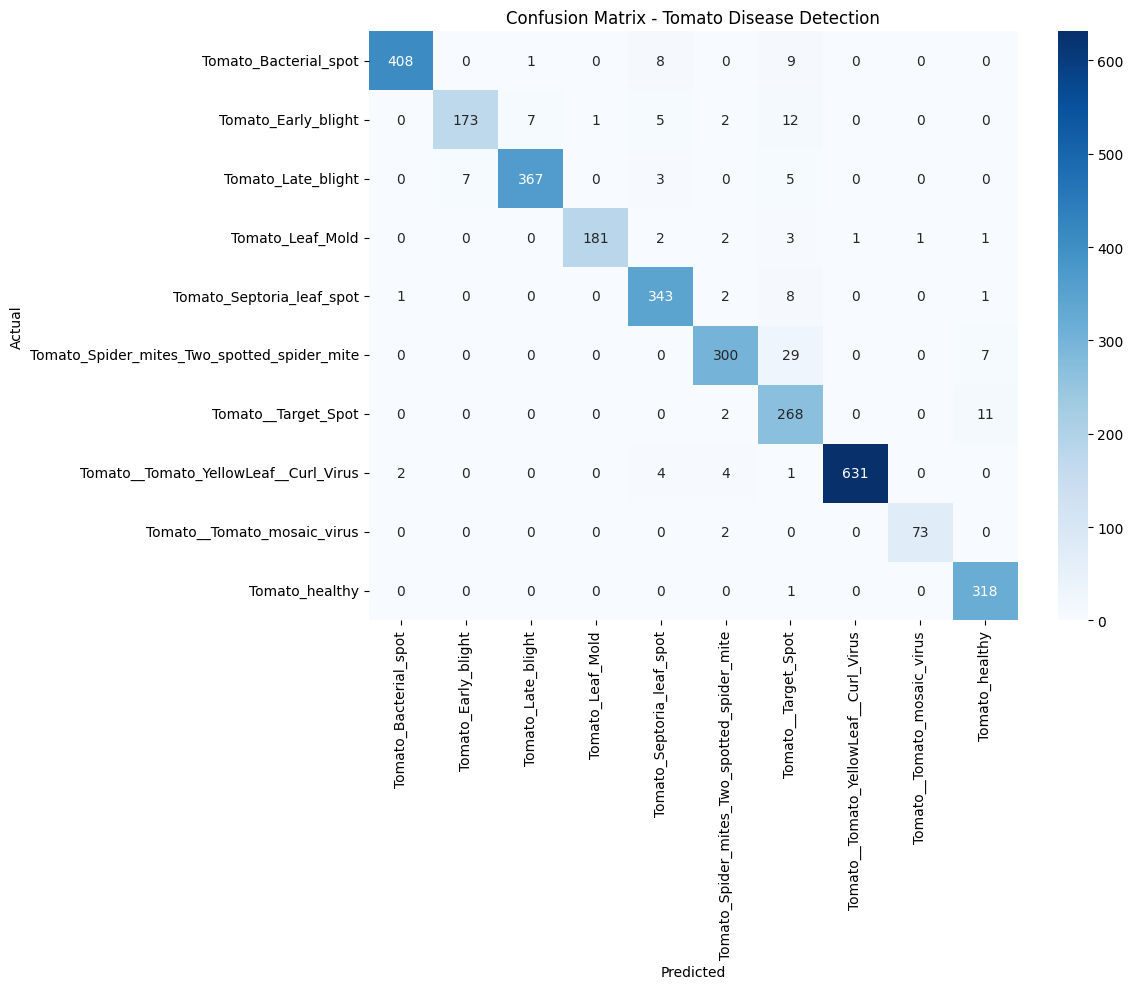

In [63]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tomato Disease Detection")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [64]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
))

                                             precision    recall  f1-score   support

                      Tomato_Bacterial_spot     0.9927    0.9577    0.9749       426
                        Tomato_Early_blight     0.9611    0.8650    0.9105       200
                         Tomato_Late_blight     0.9787    0.9607    0.9696       382
                           Tomato_Leaf_Mold     0.9945    0.9476    0.9705       191
                  Tomato_Septoria_leaf_spot     0.9397    0.9662    0.9528       355
Tomato_Spider_mites_Two_spotted_spider_mite     0.9554    0.8929    0.9231       336
                        Tomato__Target_Spot     0.7976    0.9537    0.8687       281
      Tomato__Tomato_YellowLeaf__Curl_Virus     0.9984    0.9829    0.9906       642
                Tomato__Tomato_mosaic_virus     0.9865    0.9733    0.9799        75
                             Tomato_healthy     0.9408    0.9969    0.9680       319

                                   accuracy                    